# Exploratory Data Analysis — Bank Customer Churn

**Dataset:** `Bank Customer Churn Prediction.csv`  
**Rows:** ~10,000 customers | **Targets:** one or many columns via `TARGET_COLS`

This notebook explores data quality, distributions, relationships, and target patterns before synthetic data generation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FILE_PATH = "Bank Customer Churn Prediction.csv"
ID_COLS = ["customer_id"]

# One or many targets — examples:
# TARGET_COLS = ["churn"]
# TARGET_COLS = ["churn", "active_member"]
# TARGET_COLS = ["churn", "estimated_salary"]
TARGET_COLS = ["churn"]
TARGET_KIND = {}  # optional override: {"churn": "categorical", "estimated_salary": "numeric"}
CAT_TARGET_MAX_UNIQUE = 20

BASE_CAT_COLS = ["country", "gender"]
BASE_NUM_COLS = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "credit_card", "active_member", "estimated_salary",
]


def normalize_target_cols(target_cols):
    if isinstance(target_cols, str):
        return [target_cols]
    return list(target_cols)


def classify_targets(df, target_cols, kind_overrides=None):
    kind_overrides = kind_overrides or {}
    kinds = {}
    for col in target_cols:
        if col not in df.columns:
            raise ValueError(f"Target column not in dataset: {col}")
        if col in kind_overrides:
            kinds[col] = kind_overrides[col]
        elif df[col].dtype == object or str(df[col].dtype) == "category":
            kinds[col] = "categorical"
        elif pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() <= CAT_TARGET_MAX_UNIQUE:
            kinds[col] = "categorical"
        else:
            kinds[col] = "numeric"
    cat_targets = [c for c in target_cols if kinds[c] == "categorical"]
    num_targets = [c for c in target_cols if kinds[c] == "numeric"]
    return kinds, cat_targets, num_targets


def resolve_feature_cols(target_cols):
    cat_cols = [c for c in BASE_CAT_COLS if c not in target_cols]
    num_cols = [c for c in BASE_NUM_COLS if c not in target_cols]
    return cat_cols, num_cols


## 1. Load & first look


In [2]:
df = pd.read_csv(FILE_PATH)

TARGET_COLS = normalize_target_cols(TARGET_COLS)
TARGET_KINDS, CAT_TARGET_COLS, NUM_TARGET_COLS = classify_targets(df, TARGET_COLS, TARGET_KIND)
CAT_COLS, NUM_COLS = resolve_feature_cols(TARGET_COLS)
PRIMARY_CAT_TARGET = CAT_TARGET_COLS[0] if CAT_TARGET_COLS else None

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print(f"\nTargets ({len(TARGET_COLS)}): {TARGET_COLS}")
print(f"  categorical: {CAT_TARGET_COLS}")
print(f"  numeric: {NUM_TARGET_COLS}")
print(f"Feature categorical: {CAT_COLS}")
print(f"Feature numerical: {NUM_COLS}")
df.head()


Shape: (10000, 12)

Columns: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Targets (1): ['churn']
  categorical: ['churn']
  numeric: []
Feature categorical: ['country', 'gender']
Feature numerical: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data quality


In [3]:
# types, missing, duplicates
info = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_pct": (100 * df.isna().mean()).round(2).values,
    "n_unique": df.nunique().values,
    "is_target": [c in TARGET_COLS for c in df.columns],
})
print(info.to_string(index=False))
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customer_id: {df['customer_id'].duplicated().sum()}")


          column   dtype  missing  missing_pct  n_unique  is_target
     customer_id   int64        0          0.0     10000      False
    credit_score   int64        0          0.0       460      False
         country     str        0          0.0         3      False
          gender     str        0          0.0         2      False
             age   int64        0          0.0        70      False
          tenure   int64        0          0.0        11      False
         balance float64        0          0.0      6382      False
 products_number   int64        0          0.0         4      False
     credit_card   int64        0          0.0         2      False
   active_member   int64        0          0.0         2      False
estimated_salary float64        0          0.0      9999      False
           churn   int64        0          0.0         2       True

Duplicate rows: 0
Duplicate customer_id: 0


## 3. Summary statistics


In [4]:
df[NUM_COLS + NUM_TARGET_COLS].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
products_number,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
credit_card,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
active_member,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
estimated_salary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


## 4. Target variable(s)



=== churn (categorical) ===


/tmp/ipykernel_975052/3916974056.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, ax=axes[0], palette="Set2")


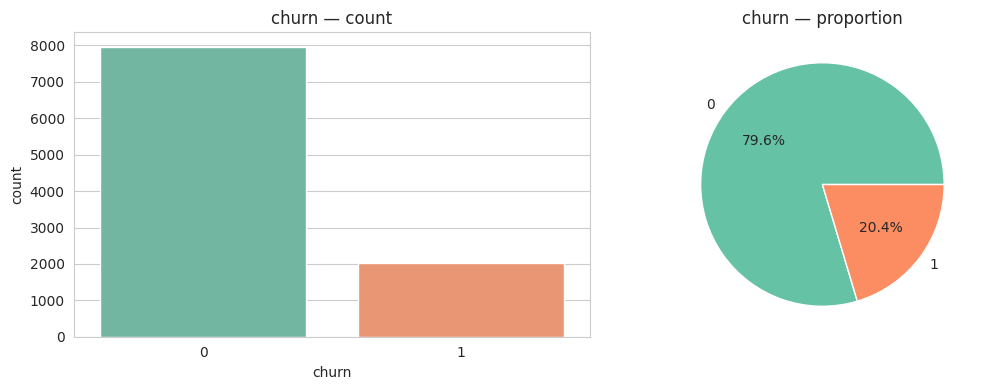

Positive rate (mean): 20.37%


In [5]:
for target in TARGET_COLS:
    kind = TARGET_KINDS[target]
    print(f"\n=== {target} ({kind}) ===")

    if kind == "categorical":
        counts = df[target].value_counts()
        pct = df[target].value_counts(normalize=True) * 100
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        sns.countplot(data=df, x=target, ax=axes[0], palette="Set2")
        axes[0].set_title(f"{target} — count")
        axes[1].pie(pct, labels=[str(v) for v in pct.index], autopct="%1.1f%%", colors=sns.color_palette("Set2"))
        axes[1].set_title(f"{target} — proportion")
        plt.tight_layout()
        plt.show()
        print(f"Positive rate (mean): {df[target].mean():.2%}" if df[target].nunique() == 2 else counts.to_string())
    else:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        sns.histplot(df[target], kde=True, bins=30, ax=axes[0], color="steelblue")
        axes[0].set_title(f"{target} — distribution")
        sns.boxplot(y=df[target], ax=axes[1], color="steelblue")
        axes[1].set_title(f"{target} — boxplot")
        plt.tight_layout()
        plt.show()
        print(df[target].describe().round(2).to_string())


## 5. Categorical features


/tmp/ipykernel_975052/2062318899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="pastel")
/tmp/ipykernel_975052/2062318899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="pastel")


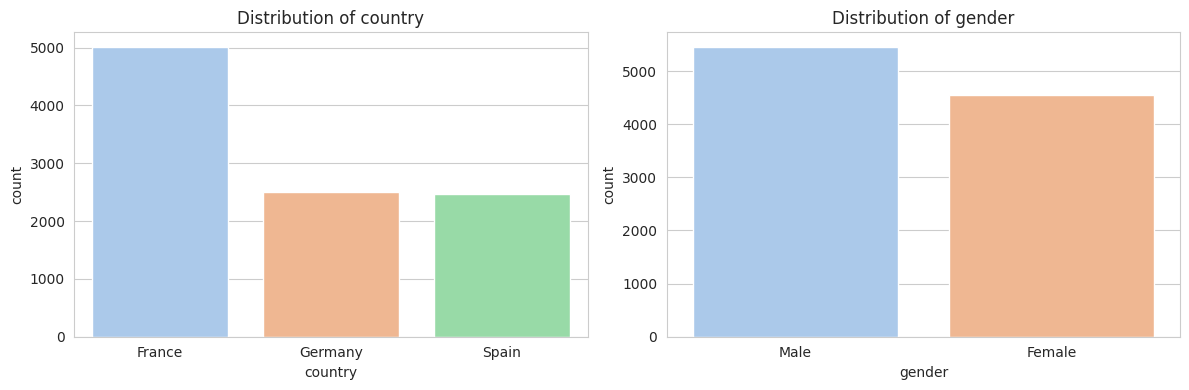


churn rate (%) by country:
country
Germany    32.44
Spain      16.67
France     16.15

churn rate (%) by gender:
gender
Female    25.07
Male      16.46


In [6]:
if CAT_COLS:
    fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(6 * len(CAT_COLS), 4))
    if len(CAT_COLS) == 1:
        axes = [axes]
    for ax, col in zip(axes, CAT_COLS):
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, ax=ax, palette="pastel")
        ax.set_title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
else:
    print("No categorical feature columns left after removing targets.")

for target in CAT_TARGET_COLS:
    for col in CAT_COLS:
        rate = df.groupby(col)[target].mean().sort_values(ascending=False) * 100
        print(f"\n{target} rate (%) by {col}:")
        print(rate.round(2).to_string())


/tmp/ipykernel_975052/2760852294.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y=target, ax=ax, palette="coolwarm")
/tmp/ipykernel_975052/2760852294.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y=target, ax=ax, palette="coolwarm")


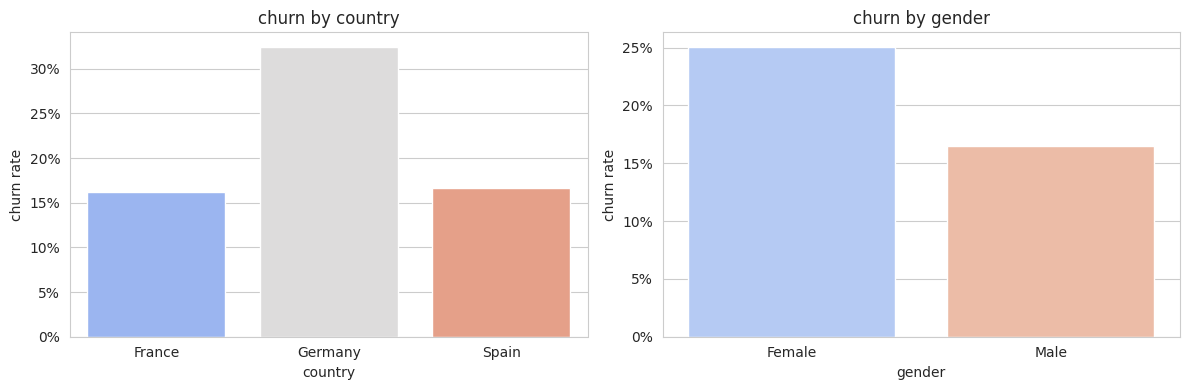

In [7]:
if CAT_TARGET_COLS and CAT_COLS:
    nrows, ncols = len(CAT_TARGET_COLS), len(CAT_COLS)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    for r, target in enumerate(CAT_TARGET_COLS):
        for c, col in enumerate(CAT_COLS):
            ax = axes[r, c]
            tmp = df.groupby(col)[target].mean().reset_index()
            sns.barplot(data=tmp, x=col, y=target, ax=ax, palette="coolwarm")
            ax.set_ylabel(f"{target} rate")
            ax.set_title(f"{target} by {col}")
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.tight_layout()
    plt.show()
else:
    print("Skipping target-by-category barplots (need at least one categorical target and feature).")


## 6. Numerical distributions


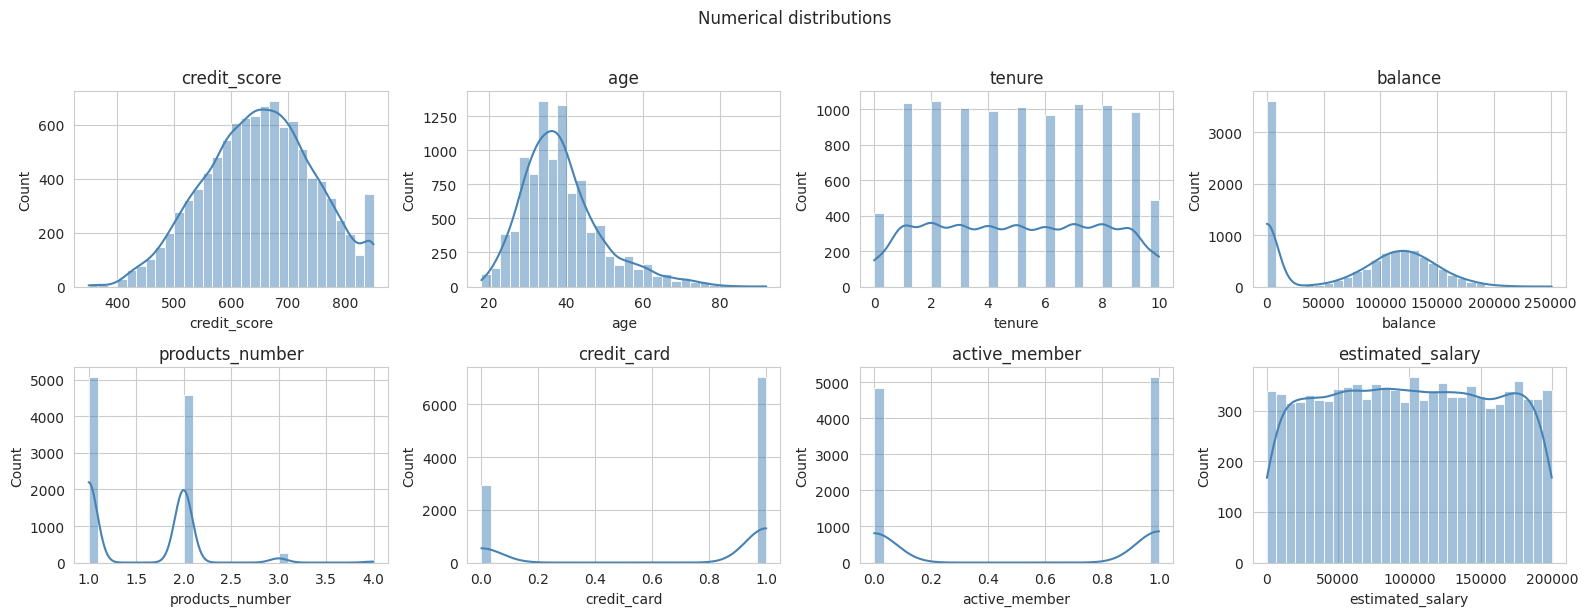

In [8]:
plot_num_cols = NUM_COLS + NUM_TARGET_COLS
if plot_num_cols:
    n = len(plot_num_cols)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(plot_num_cols):
        sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color="steelblue")
        title = col + (" (target)" if col in NUM_TARGET_COLS else "")
        axes[i].set_title(title)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Numerical distributions", y=1.02)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_975052/1815220830.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_975052/1815220830.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_975052/1815220830.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_975052/1815220830.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

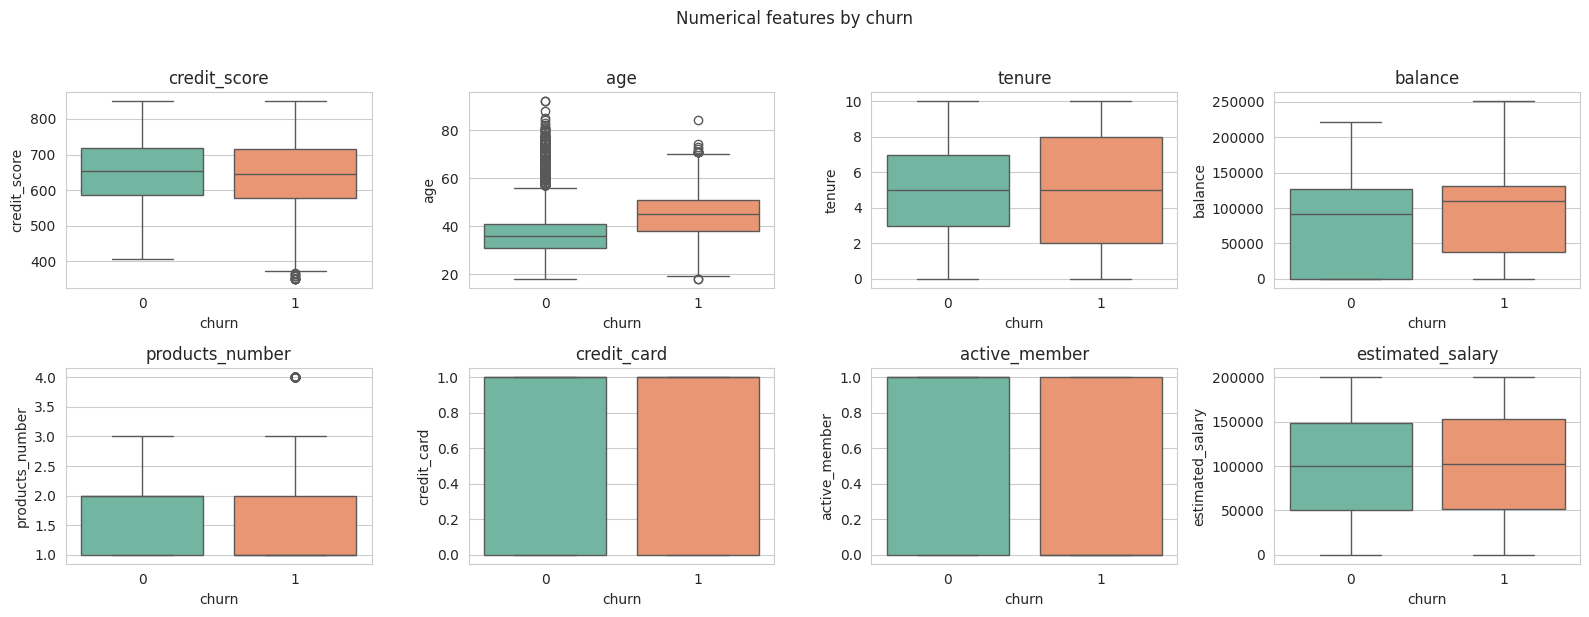

In [9]:
if CAT_TARGET_COLS and NUM_COLS:
    for target in CAT_TARGET_COLS:
        n = len(NUM_COLS)
        ncols = 4
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = np.atleast_1d(axes).ravel()
        for i, col in enumerate(NUM_COLS):
            sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette="Set2")
            axes[i].set_title(col)
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle(f"Numerical features by {target}", y=1.02)
        plt.tight_layout()
        plt.show()
elif NUM_TARGET_COLS and NUM_COLS:
    print("Numeric targets: showing correlation table instead of boxplots by target.")
    print(df[NUM_COLS + NUM_TARGET_COLS].corr().loc[NUM_TARGET_COLS, NUM_COLS].round(3).to_string())
else:
    print("Skipping numerical-by-target boxplots.")


## 7. Correlation matrix


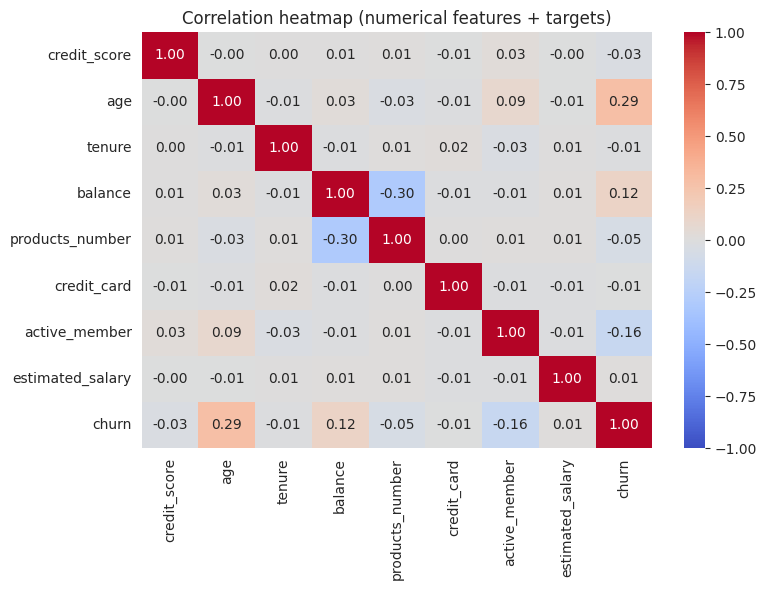


Correlation with churn (sorted):
age                 0.285
active_member      -0.156
balance             0.119
products_number    -0.048
credit_score       -0.027
tenure             -0.014
estimated_salary    0.012
credit_card        -0.007


In [10]:
corr_cols = NUM_COLS + CAT_TARGET_COLS + NUM_TARGET_COLS
corr = df[corr_cols].corr()

plt.figure(figsize=(max(8, 0.6 * len(corr_cols)), max(6, 0.6 * len(corr_cols))))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation heatmap (numerical features + targets)")
plt.tight_layout()
plt.show()

for target in TARGET_COLS:
    if target not in corr.columns:
        continue
    others = [c for c in corr_cols if c != target]
    print(f"\nCorrelation with {target} (sorted):")
    print(corr[target].drop(target).sort_values(key=abs, ascending=False).round(3).to_string())


## 8. Bivariate relationships


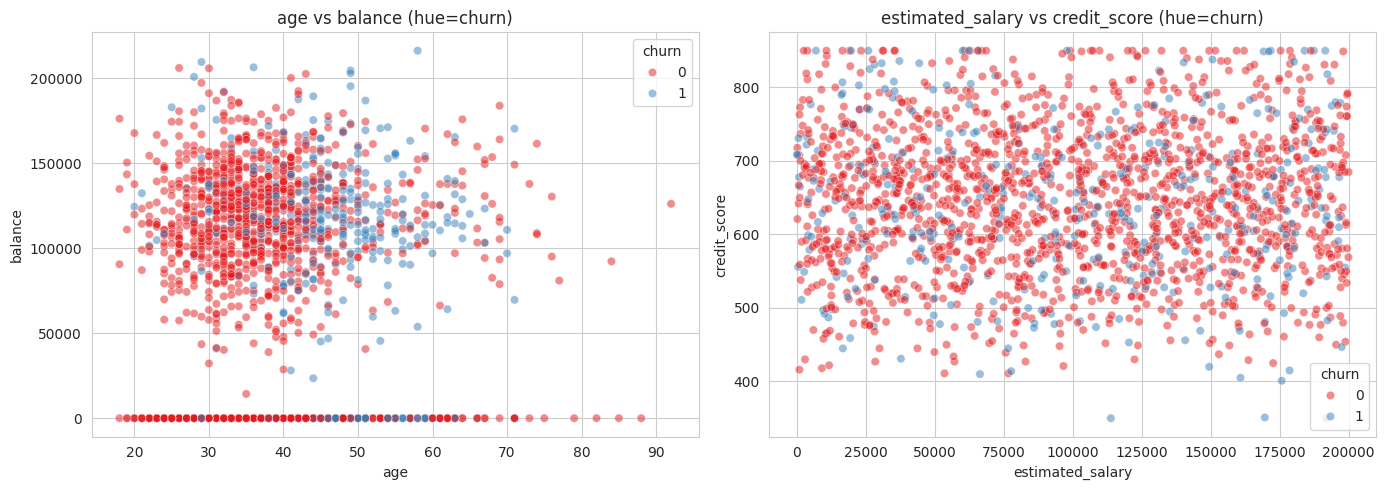

In [11]:
sample = df.sample(min(2000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hue = PRIMARY_CAT_TARGET
scatter_pairs = [("age", "balance"), ("estimated_salary", "credit_score")]

for ax, (xcol, ycol) in zip(axes, scatter_pairs):
    if xcol not in df.columns or ycol not in df.columns:
        ax.set_visible(False)
        continue
    if hue:
        sns.scatterplot(data=sample, x=xcol, y=ycol, hue=hue, alpha=0.5, ax=ax, palette="Set1")
        ax.set_title(f"{xcol} vs {ycol} (hue={hue})")
    else:
        sns.scatterplot(data=sample, x=xcol, y=ycol, alpha=0.5, ax=ax, color="steelblue")
        ax.set_title(f"{xcol} vs {ycol}")

plt.tight_layout()
plt.show()


In [12]:
if "country" in CAT_COLS:
    country_means = df.groupby("country")[NUM_COLS + TARGET_COLS].mean().round(2)
    print("Mean values by country:\n")
    print(country_means)
else:
    print("Country not in feature columns.")


Mean values by country:

         credit_score    age  tenure    balance  products_number  credit_card  \
country                                                                         
France         649.67  38.51    5.00   62092.64             1.53         0.71   
Germany        651.45  39.77    5.01  119730.12             1.52         0.71   
Spain          651.33  38.89    5.03   61818.15             1.54         0.69   

         active_member  estimated_salary  churn  
country                                          
France            0.52          99899.18   0.16  
Germany           0.50         101113.44   0.32  
Spain             0.53          99440.57   0.17  


## 9. Binary / low-cardinality flags


/tmp/ipykernel_975052/1441535461.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_rate.index.astype(str), y=target_rate.values, ax=ax, palette="viridis")
/tmp/ipykernel_975052/1441535461.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_rate.index.astype(str), y=target_rate.values, ax=ax, palette="viridis")


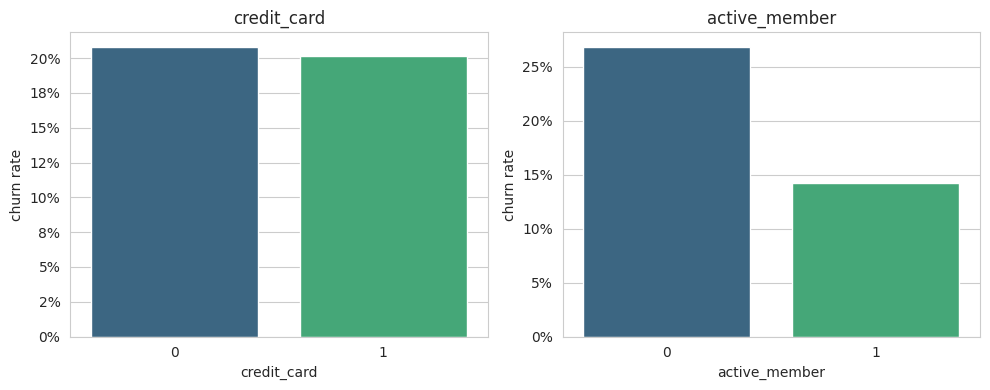

/tmp/ipykernel_975052/1441535461.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, ax=ax, palette="Set2")


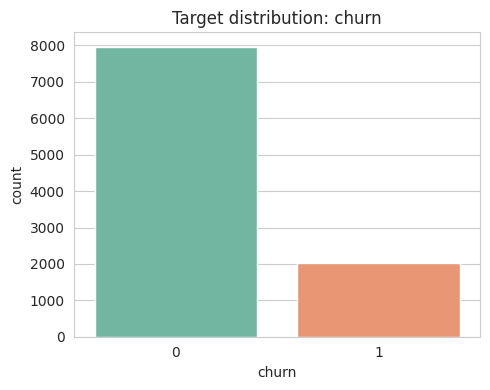

In [13]:
binary_feature_cols = [c for c in NUM_COLS if df[c].nunique() <= 2]
if binary_feature_cols and PRIMARY_CAT_TARGET:
    fig, axes = plt.subplots(1, len(binary_feature_cols), figsize=(5 * len(binary_feature_cols), 4))
    if len(binary_feature_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, binary_feature_cols):
        target_rate = df.groupby(col)[PRIMARY_CAT_TARGET].mean()
        sns.barplot(x=target_rate.index.astype(str), y=target_rate.values, ax=ax, palette="viridis")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.set_ylabel(f"{PRIMARY_CAT_TARGET} rate")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

for target in CAT_TARGET_COLS:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.countplot(data=df, x=target, ax=ax, palette="Set2")
    ax.set_title(f"Target distribution: {target}")
    plt.tight_layout()
    plt.show()


## 10. Key takeaways


In [14]:
insights = {
    "rows": len(df),
    "targets": ", ".join(TARGET_COLS),
    "median_salary": f"{df['estimated_salary'].median():,.0f}" if "estimated_salary" in df.columns else "n/a",
    "median_balance": f"{df['balance'].median():,.0f}" if "balance" in df.columns else "n/a",
    "median_age": int(df["age"].median()) if "age" in df.columns else "n/a",
}

for target in CAT_TARGET_COLS:
    insights[f"{target}_rate"] = f"{df[target].mean():.2%}"
    if "country" in CAT_COLS:
        insights[f"top_{target}_country"] = df.groupby("country")[target].mean().idxmax()
    if "gender" in CAT_COLS:
        insights[f"top_{target}_gender"] = df.groupby("gender")[target].mean().idxmax()
    if target in corr.columns:
        insights[f"highest_corr_with_{target}"] = corr[target].drop(target).abs().idxmax()

for target in NUM_TARGET_COLS:
    insights[f"{target}_median"] = f"{df[target].median():,.2f}"
    if target in corr.columns:
        insights[f"highest_corr_with_{target}"] = corr[target].drop(target).abs().idxmax()

for k, v in insights.items():
    print(f"  {k}: {v}")


  rows: 10000
  targets: churn
  median_salary: 100,194
  median_balance: 97,199
  median_age: 37
  churn_rate: 20.37%
  top_churn_country: Germany
  top_churn_gender: Female
  highest_corr_with_churn: age
